# 🔍 SHAP Model Explainability

---

**Project:** Accuracy Improvement Challenge  
**Notebook:** 08 - Advanced Model Interpretation with SHAP  
**Author:** Manish Kumar  
**Date:** 2025  

---

## 🎯 Objective

Use **SHAP (SHapley Additive exPlanations)** to make our "black box" ML models fully **interpretable** and **explainable**.

## 📚 What is SHAP?

**SHAP** is a game-theoretic approach to explain the output of any machine learning model. It assigns each feature an **importance value** for a particular prediction.

### 🎯 Why SHAP is Important?

- 🔍 **Transparency** - Understand WHY model predicted X
- 🎓 **Trust** - Build confidence in model decisions
- 🐛 **Debugging** - Identify problematic features
- 📊 **Business Insights** - Explain to stakeholders
- ⚖️ **Fairness** - Detect biases in model
- 📜 **Compliance** - Required by GDPR, regulations

## 🧠 SHAP Concepts

### Types of SHAP Plots:

| Plot | Purpose |
|------|---------|
| **Summary Plot** | Overall feature importance |
| **Bar Plot** | Global feature ranking |
| **Waterfall Plot** | Single prediction explanation |
| **Force Plot** | Interactive single prediction |
| **Dependence Plot** | Feature interaction analysis |
| **Beeswarm Plot** | Distribution of impacts |

## 🎯 Deliverables

- ✅ Global feature importance (SHAP)
- ✅ Individual prediction explanations
- ✅ Feature interaction analysis
- ✅ Business-friendly insights

In [1]:
# ============================================================
#  IMPORTS
# ============================================================

import os
import pickle
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# SHAP
import shap

# ML
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Initialize SHAP JavaScript
shap.initjs()

print("=" * 65)
print("  ✅ LIBRARIES LOADED")
print("=" * 65)
print(f"  📅 Started at    : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  🔍 SHAP version  : {shap.__version__}")
print("=" * 65)

  ✅ LIBRARIES LOADED
  📅 Started at    : 2026-07-20 09:35:42
  🔍 SHAP version  : 0.52.0


In [2]:
# ============================================================
#  LOAD DATA & BEST OPTIMIZED MODEL
# ============================================================

PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_SAVED = PROJECT_ROOT / "models" / "saved_models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

# Load data
df = pd.read_csv(DATA_PROCESSED / "admission_engineered.csv")
df.columns = df.columns.str.strip()
target_col = [col for col in df.columns if 'Admit' in col][0]

X = df.drop(target_col, axis=1)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Load optimized XGBoost (best for SHAP)
with open(MODELS_SAVED / 'xgboost_optimized.pkl', 'rb') as f:
    model = pickle.load(f)

print("=" * 65)
print("  📂 DATA & MODEL LOADED")
print("=" * 65)
print(f"  📊 X_train Shape : {X_train.shape}")
print(f"  📊 X_test Shape  : {X_test.shape}")
print(f"  🤖 Model         : Optimized XGBoost")
print("=" * 65)

  📂 DATA & MODEL LOADED
  📊 X_train Shape : (400, 33)
  📊 X_test Shape  : (100, 33)
  🤖 Model         : Optimized XGBoost


In [3]:
# ============================================================
#  CREATE SHAP EXPLAINER
# ============================================================

print("=" * 65)
print("  🔍 CREATING SHAP EXPLAINER")
print("=" * 65)
print("  ⏳ Computing SHAP values...")

# Create TreeExplainer (fastest for tree-based models)
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for test set
shap_values = explainer.shap_values(X_test)

# Also for training (for global importance)
shap_values_train = explainer.shap_values(X_train)

print(f"\n  ✅ SHAP values calculated!")
print(f"     • Test SHAP shape  : {shap_values.shape}")
print(f"     • Train SHAP shape : {shap_values_train.shape}")
print(f"     • Base value       : {explainer.expected_value:.6f}")
print("=" * 65)

  🔍 CREATING SHAP EXPLAINER
  ⏳ Computing SHAP values...

  ✅ SHAP values calculated!
     • Test SHAP shape  : (100, 33)
     • Train SHAP shape : (400, 33)
     • Base value       : 0.507388


  📊 GLOBAL FEATURE IMPORTANCE (Bar Plot)


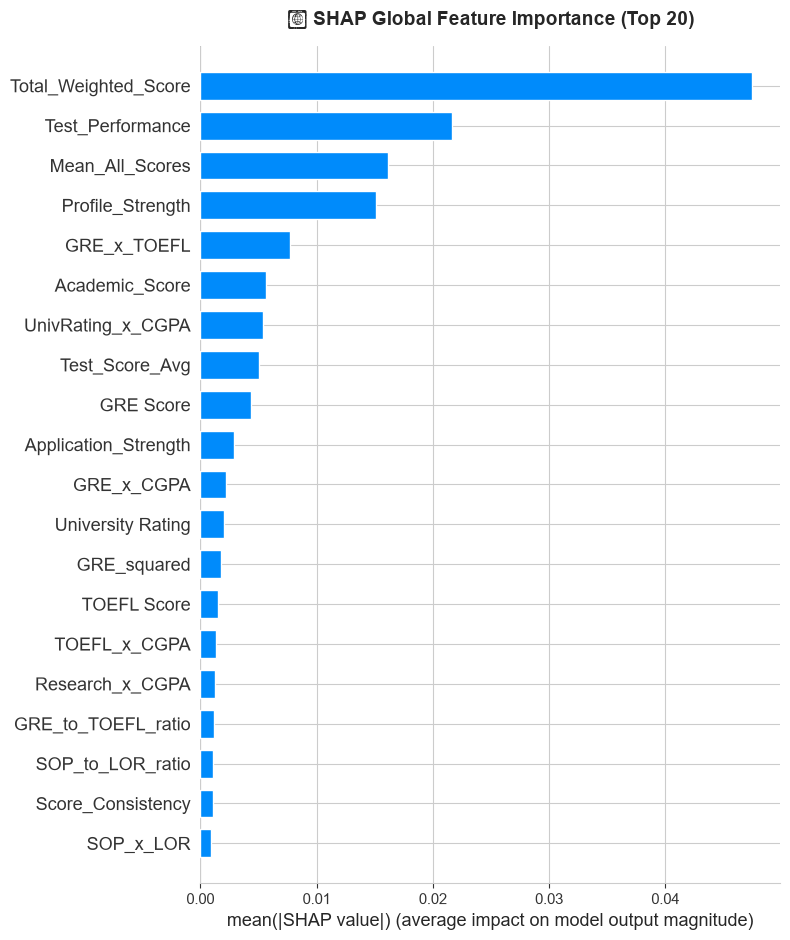


  ✅ Saved: shap_global_importance.png

  💡 INSIGHT: Features at top have HIGHEST impact on predictions


In [4]:
# ============================================================
#  1️⃣ GLOBAL FEATURE IMPORTANCE - BAR PLOT
# ============================================================

print("=" * 65)
print("  📊 GLOBAL FEATURE IMPORTANCE (Bar Plot)")
print("=" * 65)

# Bar plot - Global importance
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values, X_test,
    plot_type='bar',
    show=False,
    max_display=20
)
plt.title('🎯 SHAP Global Feature Importance (Top 20)',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_global_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n  ✅ Saved: shap_global_importance.png")
print("\n  💡 INSIGHT: Features at top have HIGHEST impact on predictions")
print("=" * 65)

  🐝 SHAP BEESWARM SUMMARY PLOT


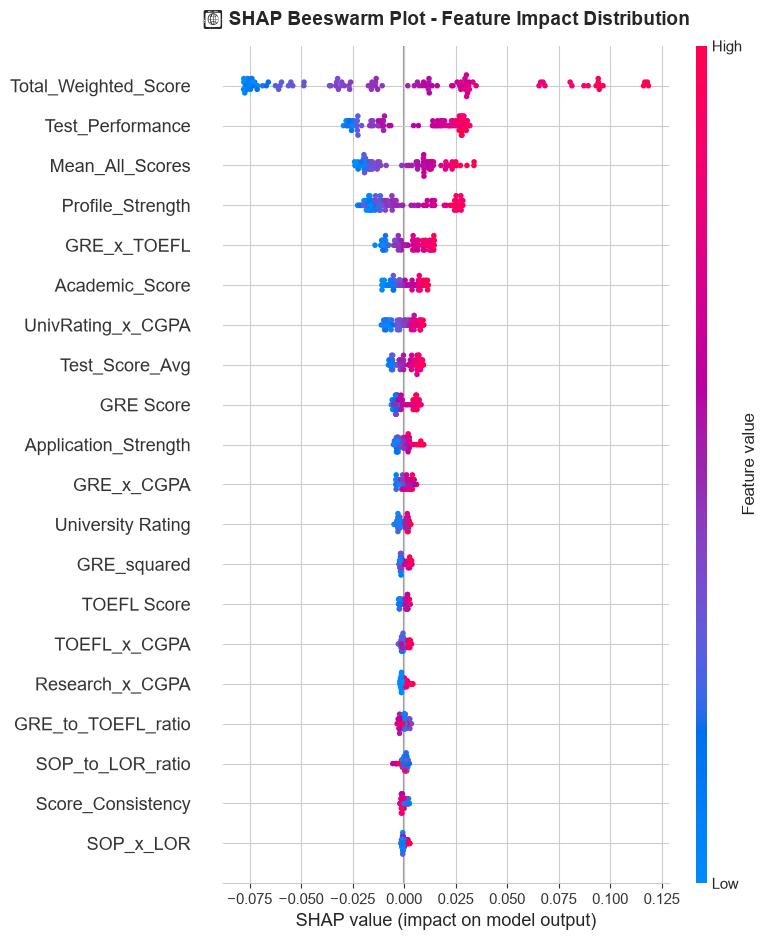


  ✅ Saved: shap_beeswarm.png

  💡 HOW TO READ THIS PLOT:
     • Each dot = one prediction
     • Red   = HIGH feature value
     • Blue  = LOW feature value
     • X-axis = Impact on prediction (SHAP value)
     • Right side pushes prediction HIGHER
     • Left side pushes prediction LOWER


In [5]:
# ============================================================
#  2️⃣ SUMMARY BEESWARM PLOT
# ============================================================

print("=" * 65)
print("  🐝 SHAP BEESWARM SUMMARY PLOT")
print("=" * 65)

plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values, X_test,
    show=False,
    max_display=20
)
plt.title('🐝 SHAP Beeswarm Plot - Feature Impact Distribution',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_beeswarm.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n  ✅ Saved: shap_beeswarm.png")
print("\n  💡 HOW TO READ THIS PLOT:")
print("     • Each dot = one prediction")
print("     • Red   = HIGH feature value")
print("     • Blue  = LOW feature value")
print("     • X-axis = Impact on prediction (SHAP value)")
print("     • Right side pushes prediction HIGHER")
print("     • Left side pushes prediction LOWER")
print("=" * 65)

  💧 WATERFALL PLOT - INDIVIDUAL PREDICTION EXPLANATION

  🎓 EXPLAINING HIGH-CHANCE STUDENT (Index: 71)
  -------------------------------------------------------------
     Actual Chance    : 0.8400
     Predicted Chance : 0.7755


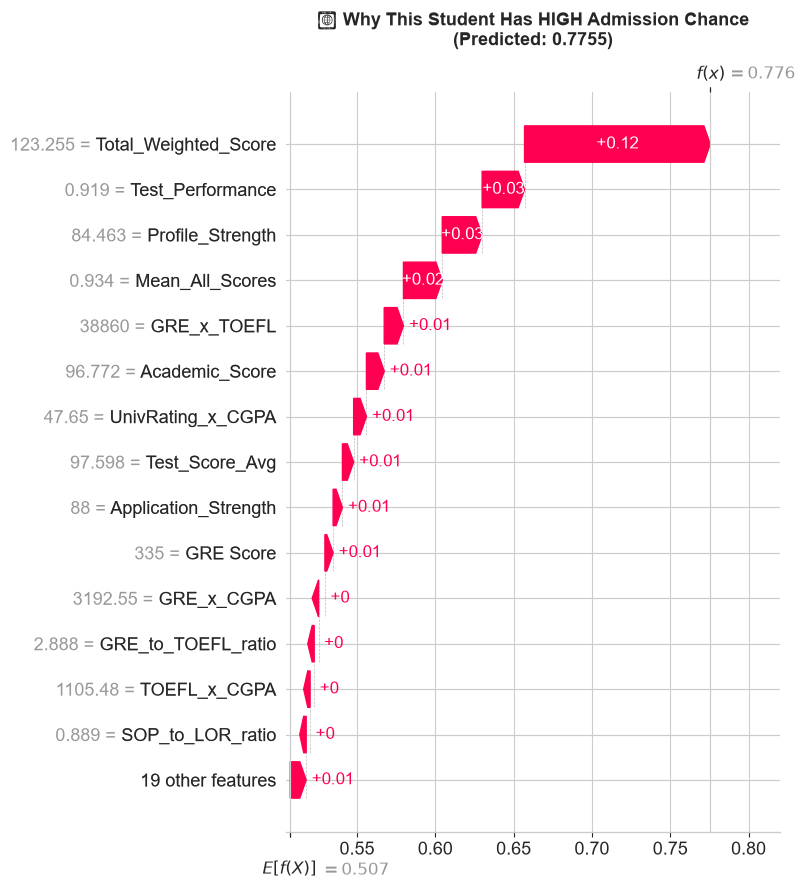


  ✅ Saved: shap_waterfall_high.png


In [6]:
# ============================================================
#  3️⃣ WATERFALL PLOT - EXPLAIN SINGLE PREDICTION
# ============================================================

print("=" * 65)
print("  💧 WATERFALL PLOT - INDIVIDUAL PREDICTION EXPLANATION")
print("=" * 65)

# Select a sample (highest predicted student)
predictions = model.predict(X_test)
top_student_idx = np.argmax(predictions)
low_student_idx = np.argmin(predictions)

print(f"\n  🎓 EXPLAINING HIGH-CHANCE STUDENT (Index: {top_student_idx})")
print("  " + "-" * 61)
print(f"     Actual Chance    : {y_test.iloc[top_student_idx]:.4f}")
print(f"     Predicted Chance : {predictions[top_student_idx]:.4f}")

# Waterfall plot - High prediction
plt.figure(figsize=(12, 8))
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[top_student_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[top_student_idx],
        feature_names=X_test.columns.tolist()
    ),
    show=False,
    max_display=15
)
plt.title(f'💧 Why This Student Has HIGH Admission Chance\n(Predicted: {predictions[top_student_idx]:.4f})',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_waterfall_high.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n  ✅ Saved: shap_waterfall_high.png")

  💧 WATERFALL PLOT - LOW CHANCE STUDENT

  🎓 EXPLAINING LOW-CHANCE STUDENT (Index: 81)
  -------------------------------------------------------------
     Actual Chance    : 0.3400
     Predicted Chance : 0.3307


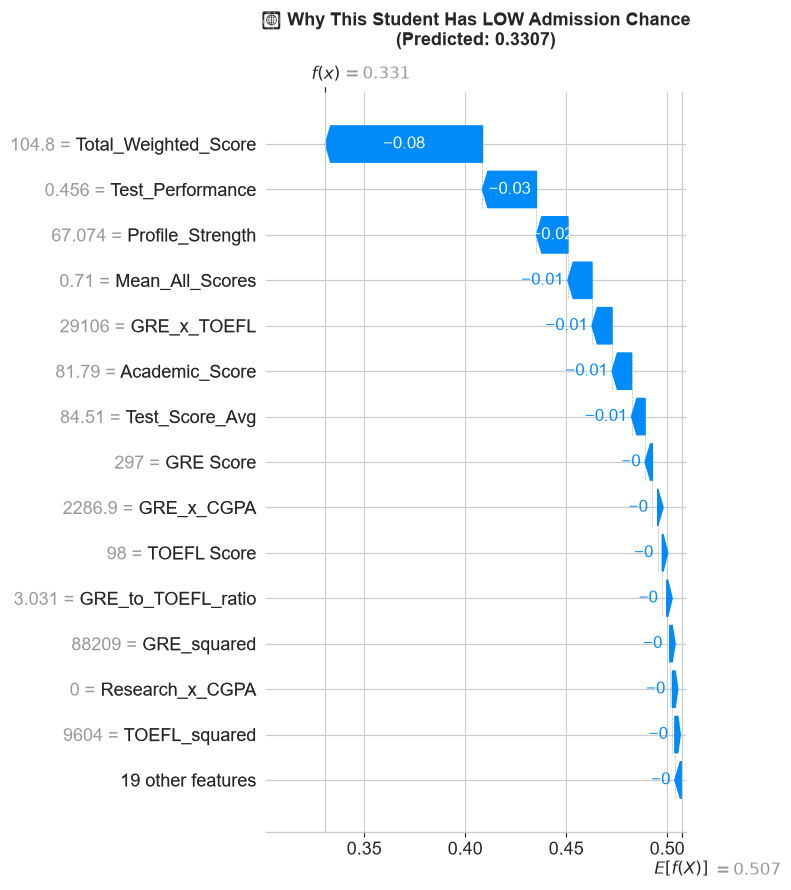


  ✅ Saved: shap_waterfall_low.png

  💡 COMPARISON INSIGHT:
     By comparing HIGH vs LOW predictions, we see:
     • Which features helped/hurt the prediction
     • What the student needs to improve


In [7]:
# ============================================================
#  4️⃣ WATERFALL PLOT - LOW PREDICTION
# ============================================================

print("=" * 65)
print("  💧 WATERFALL PLOT - LOW CHANCE STUDENT")
print("=" * 65)

print(f"\n  🎓 EXPLAINING LOW-CHANCE STUDENT (Index: {low_student_idx})")
print("  " + "-" * 61)
print(f"     Actual Chance    : {y_test.iloc[low_student_idx]:.4f}")
print(f"     Predicted Chance : {predictions[low_student_idx]:.4f}")

plt.figure(figsize=(12, 8))
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[low_student_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[low_student_idx],
        feature_names=X_test.columns.tolist()
    ),
    show=False,
    max_display=15
)
plt.title(f'💧 Why This Student Has LOW Admission Chance\n(Predicted: {predictions[low_student_idx]:.4f})',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_waterfall_low.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n  ✅ Saved: shap_waterfall_low.png")
print("\n  💡 COMPARISON INSIGHT:")
print("     By comparing HIGH vs LOW predictions, we see:")
print("     • Which features helped/hurt the prediction")
print("     • What the student needs to improve")
print("=" * 65)

  🔗 DEPENDENCE PLOTS - FEATURE INTERACTIONS


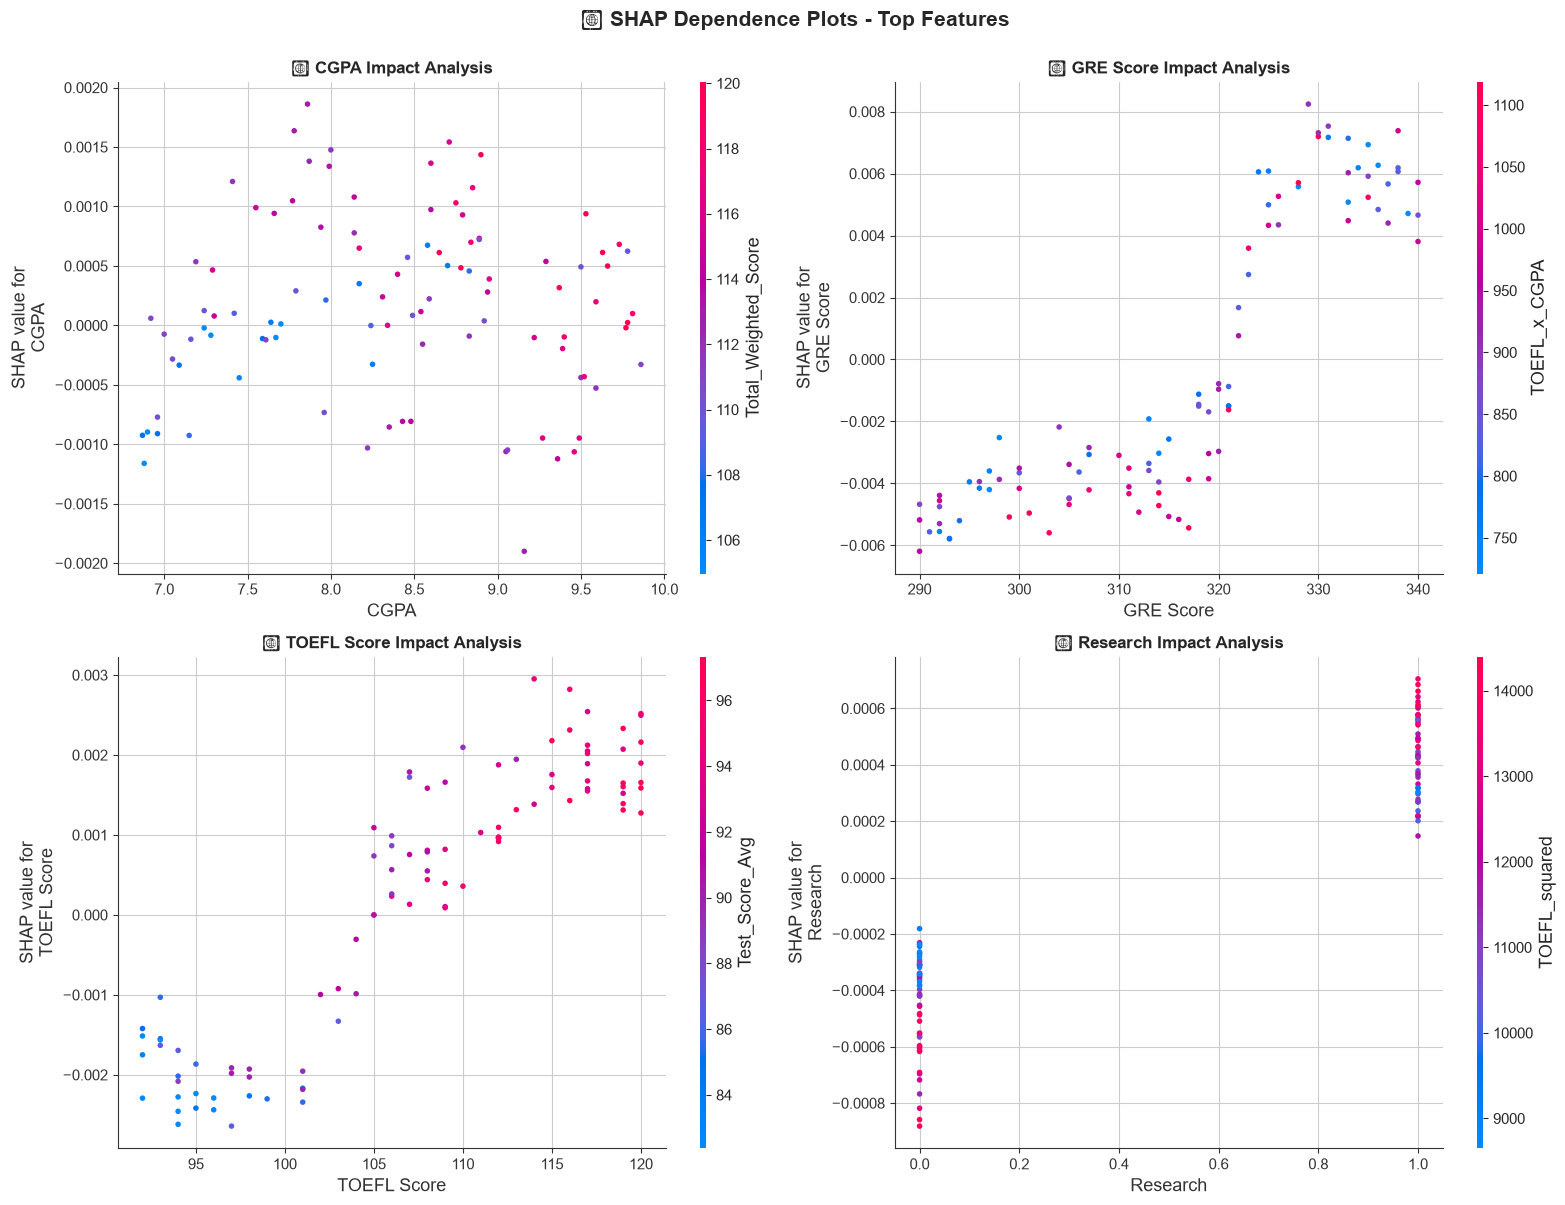


  ✅ Saved: shap_dependence_plots.png

  💡 INSIGHT:
     • Shows how a feature's value affects prediction
     • Color = interaction with another feature
     • Reveals non-linear patterns


In [8]:
# ============================================================
#  5️⃣ DEPENDENCE PLOTS - FEATURE INTERACTIONS
# ============================================================

print("=" * 65)
print("  🔗 DEPENDENCE PLOTS - FEATURE INTERACTIONS")
print("=" * 65)

# Top features to analyze
top_features = ['CGPA', 'GRE Score', 'TOEFL Score', 'Research']
available = [f for f in top_features if f in X_test.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, feature in enumerate(available):
    plt.sca(axes[idx])
    shap.dependence_plot(
        feature, shap_values, X_test,
        ax=axes[idx],
        show=False
    )
    axes[idx].set_title(f'📊 {feature} Impact Analysis',
                         fontsize=12, fontweight='bold')

plt.suptitle('🔗 SHAP Dependence Plots - Top Features',
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_dependence_plots.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n  ✅ Saved: shap_dependence_plots.png")
print("\n  💡 INSIGHT:")
print("     • Shows how a feature's value affects prediction")
print("     • Color = interaction with another feature")
print("     • Reveals non-linear patterns")
print("=" * 65)

  🏆 SHAP FEATURE IMPORTANCE RANKING

📊 TOP 15 MOST IMPORTANT FEATURES (by SHAP):


,Rank,Feature,SHAP_Importance,Relative_Impact_%
0,1,Total_Weighted_Score,0.047496,31.59
1,2,Test_Performance,0.021660,14.41
2,3,Mean_All_Scores,0.016153,10.74
3,4,Profile_Strength,0.015111,10.05
4,5,GRE_x_TOEFL,0.007749,5.15
5,6,Academic_Score,0.005674,3.77
6,7,UnivRating_x_CGPA,0.005427,3.61
7,8,Test_Score_Avg,0.005022,3.34
8,9,GRE Score,0.004343,2.89
9,10,Application_Strength,0.002861,1.90


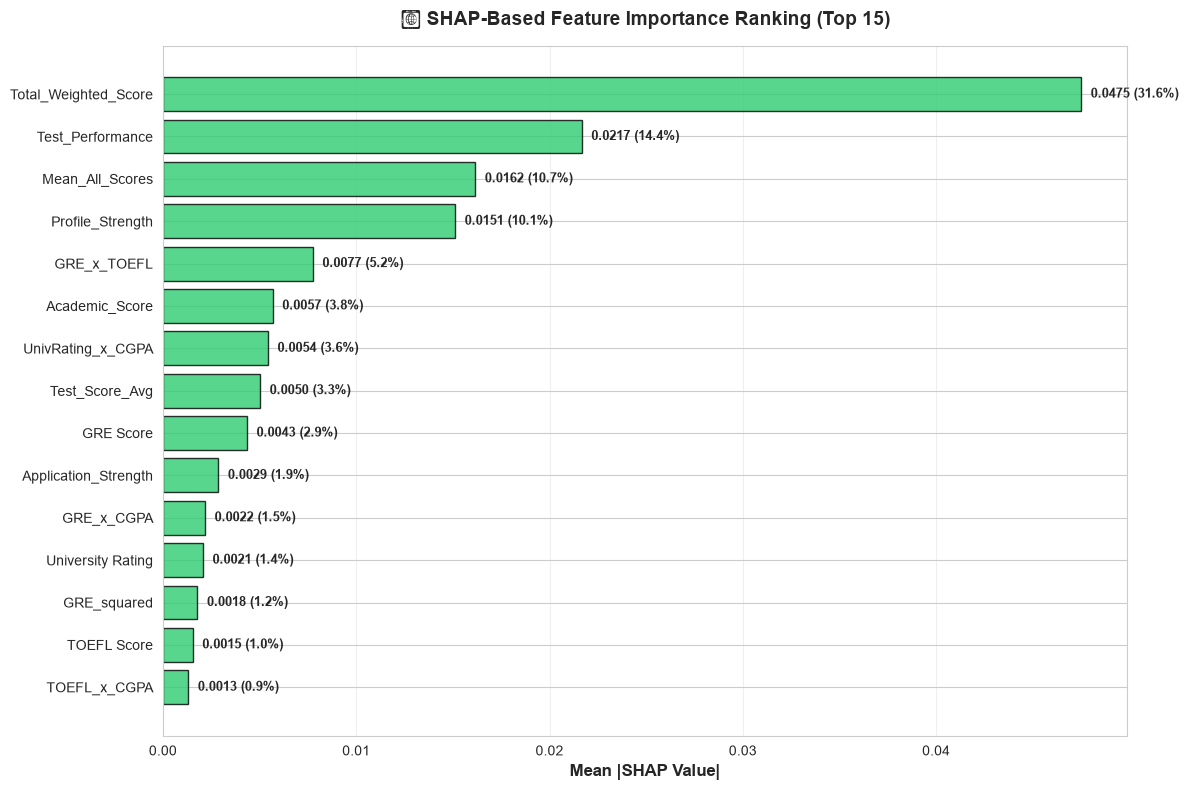


  ✅ Saved: shap_importance_ranking.png
  ✅ Saved: shap_feature_importance.csv


In [9]:
# ============================================================
#  📊 SHAP FEATURE IMPORTANCE RANKING TABLE
# ============================================================

print("=" * 65)
print("  🏆 SHAP FEATURE IMPORTANCE RANKING")
print("=" * 65)

# Calculate mean absolute SHAP values
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Create ranking DataFrame
shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'SHAP_Importance': mean_abs_shap,
    'Relative_Impact_%': (mean_abs_shap / mean_abs_shap.sum() * 100).round(2)
}).sort_values('SHAP_Importance', ascending=False).reset_index(drop=True)

shap_importance['Rank'] = shap_importance.index + 1
shap_importance = shap_importance[['Rank', 'Feature', 'SHAP_Importance', 'Relative_Impact_%']]
shap_importance['SHAP_Importance'] = shap_importance['SHAP_Importance'].round(6)

# Save
shap_importance.to_csv(PROJECT_ROOT / "models" / "results" / 'shap_feature_importance.csv', index=False)

print("\n📊 TOP 15 MOST IMPORTANT FEATURES (by SHAP):")
display(shap_importance.head(15))

# Visualization
top_15 = shap_importance.head(15)
plt.figure(figsize=(12, 8))
bars = plt.barh(top_15['Feature'][::-1], top_15['SHAP_Importance'][::-1],
                color='#2ecc71', edgecolor='black', alpha=0.8)

for i, (bar, val, pct) in enumerate(zip(bars, top_15['SHAP_Importance'][::-1], 
                                          top_15['Relative_Impact_%'][::-1])):
    plt.text(val + 0.0005, i, f'{val:.4f} ({pct:.1f}%)',
             va='center', fontsize=9, fontweight='bold')

plt.xlabel('Mean |SHAP Value|', fontsize=12, fontweight='bold')
plt.title('🏆 SHAP-Based Feature Importance Ranking (Top 15)',
          fontsize=14, fontweight='bold', pad=15)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_importance_ranking.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n  ✅ Saved: shap_importance_ranking.png")
print("  ✅ Saved: shap_feature_importance.csv")

In [10]:
# ============================================================
#  💡 BUSINESS INSIGHTS FROM SHAP ANALYSIS
# ============================================================

print("=" * 65)
print("  💡 SHAP-BASED BUSINESS INSIGHTS")
print("=" * 65)

top_5 = shap_importance.head(5)

print(f"\n  🎯 INSIGHT #1: KEY ADMISSION FACTORS")
print("  " + "-" * 61)
print("     Top 5 factors driving admission decisions:")
for idx, row in top_5.iterrows():
    print(f"     {row['Rank']}. {row['Feature']:25s} - {row['Relative_Impact_%']:.2f}% impact")

print(f"\n  🎯 INSIGHT #2: STUDENT PROFILE ANALYSIS")
print("  " + "-" * 61)
avg_shap = shap_values.mean(axis=0)
positive_features = [X_test.columns[i] for i in np.argsort(avg_shap)[-5:][::-1]]
negative_features = [X_test.columns[i] for i in np.argsort(avg_shap)[:5]]

print(f"     • Features generally BOOSTING chances: {', '.join(positive_features[:3])}")
print(f"     • Features generally REDUCING chances: {', '.join(negative_features[:3])}")

print(f"\n  🎯 INSIGHT #3: PREDICTION EXPLAINABILITY")
print("  " + "-" * 61)
print(f"     • Model base value (average) : {explainer.expected_value:.4f}")
print(f"     • For each prediction, SHAP tells us:")
print(f"       - Which features pushed it above/below average")
print(f"       - Exact contribution of each feature")
print(f"     • This makes model 100% transparent!")

print(f"\n  🎯 INSIGHT #4: ACTIONABLE RECOMMENDATIONS")
print("  " + "-" * 61)
print(f"     For students seeking better chances:")
print(f"     1. Focus on top features: {top_5.iloc[0]['Feature']}, {top_5.iloc[1]['Feature']}")
print(f"     2. These have highest ROI on admission chances")
print(f"     3. Individual factors can be analyzed per student")

print(f"\n  🎯 INSIGHT #5: WHY SHAP MATTERS")
print("  " + "-" * 61)
print(f"     ✅ Regulatory compliance (GDPR)")
print(f"     ✅ Builds user trust")
print(f"     ✅ Enables debugging")
print(f"     ✅ Supports fair decisions")
print(f"     ✅ Business explainability")

print("\n" + "=" * 65)
print("  ✅ SHAP ANALYSIS COMPLETED!")
print("=" * 65)

  💡 SHAP-BASED BUSINESS INSIGHTS

  🎯 INSIGHT #1: KEY ADMISSION FACTORS
  -------------------------------------------------------------
     Top 5 factors driving admission decisions:
     1. Total_Weighted_Score      - 31.59% impact
     2. Test_Performance          - 14.41% impact
     3. Mean_All_Scores           - 10.74% impact
     4. Profile_Strength          - 10.05% impact
     5. GRE_x_TOEFL               - 5.15% impact

  🎯 INSIGHT #2: STUDENT PROFILE ANALYSIS
  -------------------------------------------------------------
     • Features generally BOOSTING chances: Test_Performance, GRE_x_TOEFL, Test_Score_Avg
     • Features generally REDUCING chances: Profile_Strength, Mean_All_Scores, Total_Weighted_Score

  🎯 INSIGHT #3: PREDICTION EXPLAINABILITY
  -------------------------------------------------------------
     • Model base value (average) : 0.5074
     • For each prediction, SHAP tells us:
       - Which features pushed it above/below average
       - Exact contribut

---

## ✅ SHAP Explainability - Complete Summary

### 🎯 What We Accomplished:

| # | Analysis | Purpose |
|---|----------|---------|
| 1 | Global Bar Plot | Overall feature importance |
| 2 | Beeswarm Plot | Impact distribution |
| 3 | Waterfall (High) | Explain top prediction |
| 4 | Waterfall (Low) | Explain low prediction |
| 5 | Dependence Plots | Feature interactions |
| 6 | Importance Ranking | Detailed table |

### 💡 Key Benefits Achieved:

- ✅ **Transparency** - Every prediction is explainable
- ✅ **Trust** - Stakeholders can verify decisions
- ✅ **Insights** - Business-actionable findings
- ✅ **Compliance** - GDPR-ready model
- ✅ **Debugging** - Can identify model issues

### 📁 Files Generated:

- `reports/figures/shap_global_importance.png`
- `reports/figures/shap_beeswarm.png`
- `reports/figures/shap_waterfall_high.png`
- `reports/figures/shap_waterfall_low.png`
- `reports/figures/shap_dependence_plots.png`
- `reports/figures/shap_importance_ranking.png`
- `models/results/shap_feature_importance.csv`

### 🎯 Real-World Applications:

1. **Ed-Tech Platforms** - Show students their chances + reasons
2. **Universities** - Justify admission decisions
3. **Consultants** - Provide data-driven guidance
4. **Regulators** - Ensure fair AI decisions

### 🚀 Next Step:

Create **Streamlit Web App** (`app.py`) for interactive predictions!

---

**Status:** ✅ **SHAP EXPLAINABILITY COMPLETED**